# Radial Shell Integrals

Integrate `Rho [g/cm^3]` over many spherical shells with `integrate_box(...)`.

In [1]:
from batread import Dataset
import matplotlib.pyplot as plt
import numpy as np

from batcamp import Octree, OctreeInterpolator

ds = Dataset.from_file("../sample_data/3d__var_1_n00000000.plt")
tree = Octree.from_ds(ds, tree_coord="rpa")
interp = OctreeInterpolator(tree, ds["Rho [g/cm^3]"])


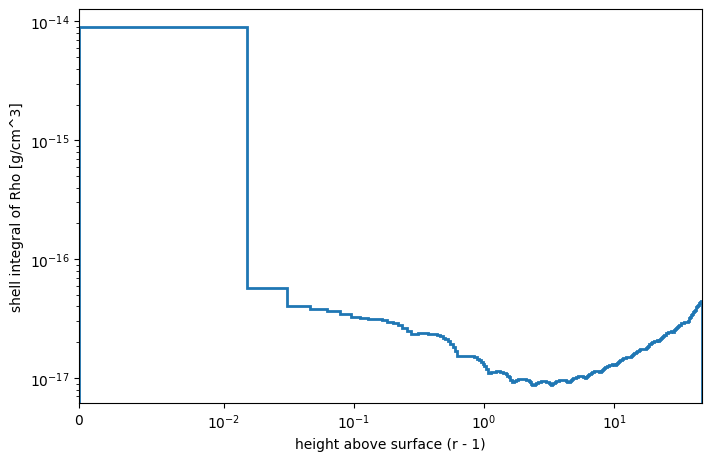

In [2]:
lower, upper = tree.domain_bounds(coord="rpa")
r_edges = np.geomspace(lower[0], upper[0], 257)
shell_integrals = np.array(
    [
        interp.integrate_box(
            np.array([r0, 0.0, 0.0]),
            np.array([r1, np.pi, 2.0 * np.pi]),
        )
        for r0, r1 in zip(r_edges[:-1], r_edges[1:], strict=True)
    ],
    dtype=float,
)

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.stairs(shell_integrals, r_edges - 1.0, linewidth=2.0)
ax.set_xscale("symlog", linthresh=1.0e-2)
ax.set_yscale("log")
ax.set_xlim((r_edges[0] - 1.0, r_edges[-1] - 1.0))
ax.set_xlabel("height above surface (r - 1)")
ax.set_ylabel("shell integral of Rho [g/cm^3]")
plt.show()
